--- EJERCICIO 5: Filtros de Acentuado Frecuencial ---


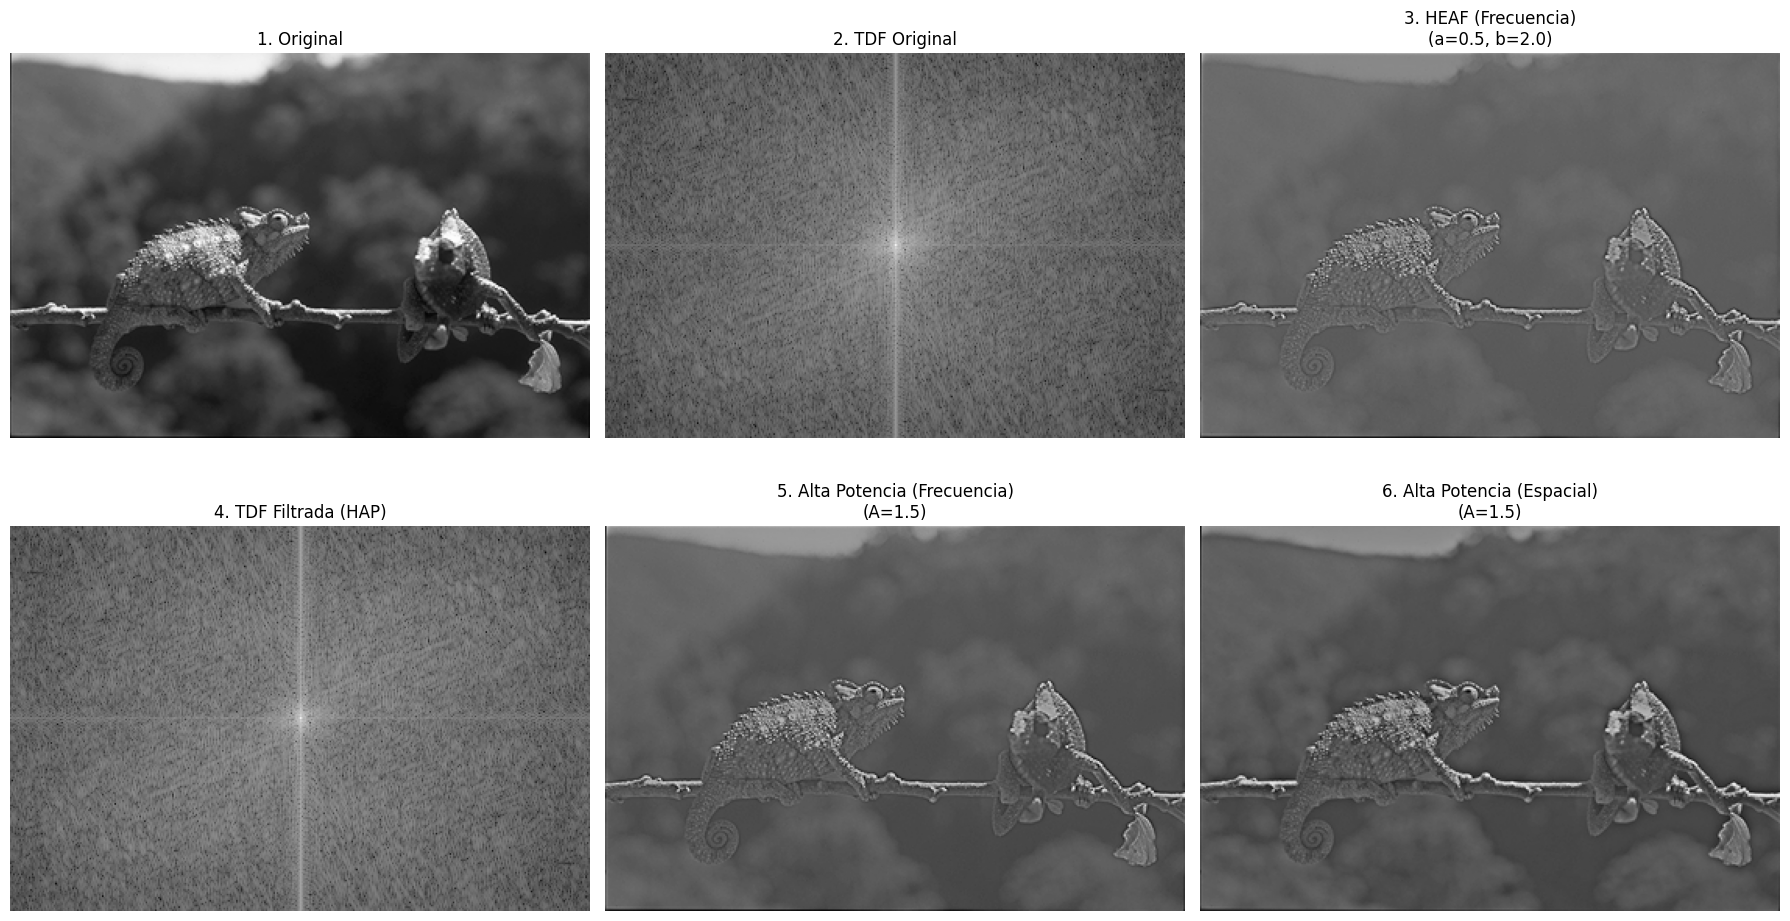

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("--- EJERCICIO 5: Filtros de Acentuado Frecuencial ---")

# 1. Cargar imagen
img = cv2.imread('camaleon.tif', cv2.IMREAD_GRAYSCALE)

if img is not None:
    # 2. Calcular TDF y centrar
    fshift = np.fft.fftshift(np.fft.fft2(img))
    espectro_orig = np.log(np.abs(fshift) + 1)
    
    # 3. Crear Filtro Pasa-Altos Base (H_PA) - Usaremos un Gaussiano
    filas, columnas = img.shape
    x, y = np.ogrid[:filas, :columnas]
    centro_x, centro_y = filas // 2, columnas // 2
    D2 = (x - centro_x)**2 + (y - centro_y)**2
    
    D0 = 40  # Frecuencia de corte
    H_PB = np.exp(-D2 / (2 * (D0**2))) # Base Pasa-bajos
    H_PA = 1 - H_PB                    # Base Pasa-altos
    
    # ---------------------------------------------------------
    # 4. APLICAR FILTROS FRECUENCIALES
    # ---------------------------------------------------------
    # Filtro de Alta Potencia (HAP)
    A = 1.5
    H_AP = (A - 1) + H_PA
    img_HAP = np.real(np.fft.ifft2(np.fft.ifftshift(fshift * H_AP)))
    
    # Filtro de Énfasis de Alta Frecuencia (HEAF)
    a, b = 0.5, 2.0
    H_EAF = a + b * H_PA
    img_HEAF = np.real(np.fft.ifft2(np.fft.ifftshift(fshift * H_EAF)))
    
    # ---------------------------------------------------------
    # 5. FILTRO ESPACIAL (Para comparación Punto 3)
    # ---------------------------------------------------------
    # Espacial: f_AP = (A-1)*original + f_PA_espacial
    # Calculamos pasa-bajos espacial (difuminado)
    img_blur = cv2.GaussianBlur(img, (21, 21), 0)
    
    # Convertimos a float para evitar truncamientos en la resta
    img_float = np.float32(img)
    blur_float = np.float32(img_blur)
    
    # Pasa-altos espacial = Original - Blur
    f_PA_espacial = img_float - blur_float
    
    # Alta Potencia Espacial
    img_HAP_espacial = (A - 1) * img_float + f_PA_espacial
    
    # ---------------------------------------------------------
    # 6. NORMALIZACIÓN Y VISUALIZACIÓN
    # ---------------------------------------------------------
    # Normalizamos todo a 0-255 para graficar correctamente
    def normalizar(imagen):
        return cv2.normalize(imagen, None, 0, 255, cv2.NORM_MINMAX, dtype=cv2.CV_8U)

    fig, axs = plt.subplots(2, 3, figsize=(18, 10))
    
    # Fila 1: Imagen y Espectro Original + Énfasis Frecuencial
    axs[0, 0].imshow(img, cmap='gray'); axs[0, 0].set_title('1. Original'); axs[0, 0].axis('off')
    axs[0, 1].imshow(espectro_orig, cmap='gray'); axs[0, 1].set_title('2. TDF Original'); axs[0, 1].axis('off')
    axs[0, 2].imshow(normalizar(img_HEAF), cmap='gray'); axs[0, 2].set_title(f'3. HEAF (Frecuencia)\n(a={a}, b={b})'); axs[0, 2].axis('off')
    
    # Fila 2: Comparativa HAP Frecuencia vs Espacial
    # Mostramos el espectro del filtro HAP
    axs[1, 0].imshow(np.log(np.abs(fshift * H_AP) + 1), cmap='gray'); axs[1, 0].set_title('4. TDF Filtrada (HAP)'); axs[1, 0].axis('off')
    axs[1, 1].imshow(normalizar(img_HAP), cmap='gray'); axs[1, 1].set_title(f'5. Alta Potencia (Frecuencia)\n(A={A})'); axs[1, 1].axis('off')
    axs[1, 2].imshow(normalizar(img_HAP_espacial), cmap='gray'); axs[1, 2].set_title(f'6. Alta Potencia (Espacial)\n(A={A})'); axs[1, 2].axis('off')
    
    plt.tight_layout()
    plt.show()

else:
    print("⚠️ Error: No se encontró la imagen 'camaleon.tif'.")

### Ejercicio 5: Filtros de acentuado en el dominio frecuencial

**1. Definición de las Funciones de Transferencia**
La idea central de estos filtros es sumar la imagen original (que contiene las bajas frecuencias) con el resultado de un filtro pasa-altos (que contiene los bordes).
* **Filtro de Alta Potencia (High-Boost - HAP):** $H_{AP} = (A - 1) + H_{PA}$
    Donde $A$ es un factor de amplificación ($A \ge 1$). La constante $(A-1)$ permite que pasen las bajas frecuencias (el fondo de la imagen). Si $A=1$, se comporta como un pasa-altos puro. Si $A > 1$, se recupera la imagen original pero con los bordes sumados.
* **Filtro de Énfasis de Alta Frecuencia (HEAF):**
    $H_{EAF} = a + b \cdot H_{PA}$
    Es una versión más flexible. La constante $a$ controla cuánta iluminación de fondo se retiene (suele ser $< 1$), y la constante $b$ controla cuánto se amplifican los bordes.

**3. Comparativa: Alta Potencia en Frecuencia vs. Espacial**
Matemáticamente, ambos métodos son equivalentes. 
* En el **dominio espacial**, la Alta Potencia se calcula restando una versión difuminada (pasa-bajos) a la original amplificada: $f_{AP} = A \cdot f(x,y) - f_{PB}(x,y)$.
* En el **dominio frecuencial**, es una simple multiplicación matricial punto a punto.
* **Diferencia práctica:** El método espacial es más rápido computacionalmente para núcleos (kernels) pequeños (ej. 3x3). Sin embargo, el método frecuencial es más preciso, no sufre de artefactos de borde y permite un control absoluto y suave sobre la frecuencia de corte sin importar el tamaño equivalente del kernel.